## **Import Libraries**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt 
from sklearn.naive_bayes import GaussianNB,BernoulliNB,MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,recall_score,precision_score,confusion_matrix,classification_report
from time import time 
from sklearn.preprocessing import StandardScaler

In [80]:
import warnings
warnings.filterwarnings("ignore")

## **Read Data**

In [2]:
df = pd.read_csv("adult.csv")
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [3]:
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


### **Handling Errors**

In [5]:
mode = df["occupation"].mode()[0]
mode

'Prof-specialty'

In [6]:
df["occupation"].isnull().sum()

np.int64(0)

In [81]:
df["occupation"].replace('?' , '' ,inplace = True)

In [8]:
df["occupation"] = df["occupation"].astype(str)

In [10]:
df["occupation"].replace('' , mode ,inplace = True)

In [11]:
df["occupation"]

0        Machine-op-inspct
1          Farming-fishing
2          Protective-serv
3        Machine-op-inspct
4           Prof-specialty
               ...        
48837         Tech-support
48838    Machine-op-inspct
48839         Adm-clerical
48840         Adm-clerical
48841      Exec-managerial
Name: occupation, Length: 48842, dtype: object

In [12]:
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,Prof-specialty,Own-child,White,Female,0,0,30,United-States,<=50K


In [13]:
mode1 = df["workclass"].mode()[0]
mode1

'Private'

In [14]:
df["workclass"].replace('?' , '' ,inplace = True)

In [15]:
df["workclass"] = df["workclass"].astype(str)

In [16]:
df["workclass"].replace('' , mode1 ,inplace = True)

In [17]:
df["workclass"]

0             Private
1             Private
2           Local-gov
3             Private
4             Private
             ...     
48837         Private
48838         Private
48839         Private
48840         Private
48841    Self-emp-inc
Name: workclass, Length: 48842, dtype: object

In [18]:
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,Private,103497,Some-college,10,Never-married,Prof-specialty,Own-child,White,Female,0,0,30,United-States,<=50K


## **Encoding**

In [19]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder

In [20]:
oo = LabelEncoder()

In [21]:
df["workclass"] = oo.fit_transform(df[["workclass"]])

In [22]:
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,3,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,3,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,1,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,3,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,3,103497,Some-college,10,Never-married,Prof-specialty,Own-child,White,Female,0,0,30,United-States,<=50K


In [23]:
df["education"] = oo.fit_transform(df[["education"]])

In [24]:
df["marital-status"] = oo.fit_transform(df[["marital-status"]])

In [25]:
df["race"] = oo.fit_transform(df[["race"]])

In [26]:
df["native-country"] = oo.fit_transform(df[["native-country"]])

In [27]:
df["occupation"] = oo.fit_transform(df[["occupation"]])

In [28]:
df["gender"] = oo.fit_transform(df[["gender"]])

In [29]:
df["relationship"] = oo.fit_transform(df[["relationship"]])

In [30]:
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,3,226802,1,7,4,6,3,2,1,0,0,40,39,<=50K
1,38,3,89814,11,9,2,4,0,4,1,0,0,50,39,<=50K
2,28,1,336951,7,12,2,10,0,4,1,0,0,40,39,>50K
3,44,3,160323,15,10,2,6,0,2,1,7688,0,40,39,>50K
4,18,3,103497,15,10,4,9,3,4,0,0,0,30,39,<=50K


In [31]:
df["income"] = oo.fit_transform(df[["income"]])

In [32]:
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,3,226802,1,7,4,6,3,2,1,0,0,40,39,0
1,38,3,89814,11,9,2,4,0,4,1,0,0,50,39,0
2,28,1,336951,7,12,2,10,0,4,1,0,0,40,39,1
3,44,3,160323,15,10,2,6,0,2,1,7688,0,40,39,1
4,18,3,103497,15,10,4,9,3,4,0,0,0,30,39,0


In [33]:
df["income"].unique()

array([0, 1])

## **Data Splitting**

In [34]:
X = df.drop("income",axis = 1)
y = df["income"]

In [35]:
X_Tr , X_Te ,y_Tr , y_Te = train_test_split(X , y,test_size=0.3 ,random_state=42)

## **Data Scalling**

In [36]:
scaler = StandardScaler()

In [37]:
X_Tr_scaled = scaler.fit_transform(X_Tr)
X_Te_scaled = scaler.transform(X_Te)

## **KNN**

In [38]:
from sklearn.neighbors import KNeighborsClassifier

In [39]:
knn = KNeighborsClassifier(n_neighbors=11)

In [40]:
knn.fit(X_Tr_scaled, y_Tr)

,n_neighbors,11
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [41]:
y_pred_knn = knn.predict(X_Te_scaled)

In [42]:
print("KNN Results:")
print("Accuracy:", accuracy_score(y_Te, y_pred_knn))
print("Confusion Matrix:")
print(confusion_matrix(y_Te, y_pred_knn))
print("Classification Report:")
print(classification_report(y_Te, y_pred_knn))

KNN Results:
Accuracy: 0.8434450283218453
Confusion Matrix:
[[10317   916]
 [ 1378  2042]]
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.92      0.90     11233
           1       0.69      0.60      0.64      3420

    accuracy                           0.84     14653
   macro avg       0.79      0.76      0.77     14653
weighted avg       0.84      0.84      0.84     14653



### **Confusion Matrix Figure**

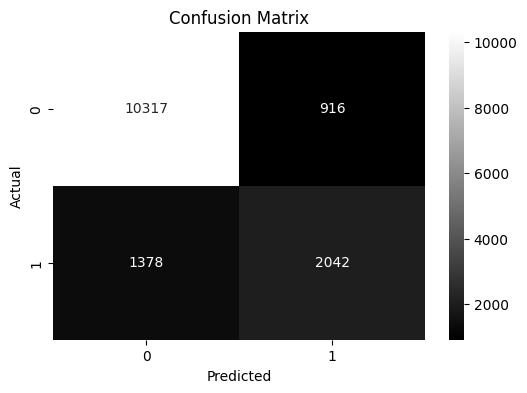

In [43]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_Te, y_pred_knn), annot=True, fmt='d', cmap='gray')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### **Find Optimal K**

In [44]:
k_range = range(1,21)
errors =[]

for k in k_range:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_Tr_scaled, y_Tr)
    y_pred_knns = model.predict(X_Te_scaled)
    
    accuracies = accuracy_score(y_Te, y_pred_knns)
    error = 1 - accuracies
    
    errors.append(error)

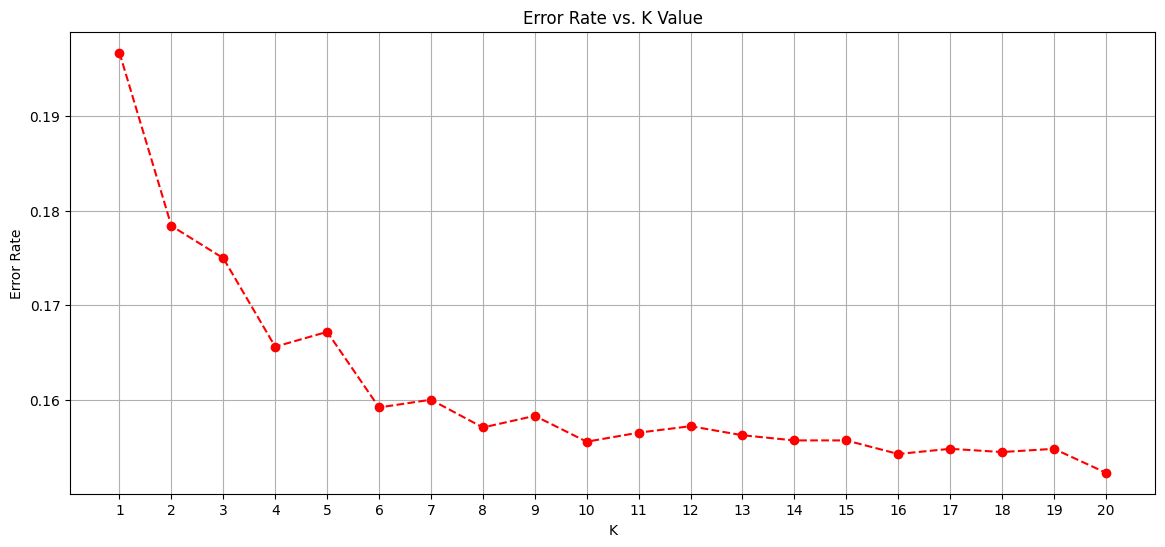

In [45]:
plt.figure(figsize=(14,6))
plt.plot(k_range, errors, color='red', linestyle='--', marker='o')
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.xticks(range(1, 21))
plt.grid(True)
plt.show()

### **LogisticRegression**

In [46]:
from sklearn.linear_model import LogisticRegression

In [47]:
L_R = LogisticRegression()

In [48]:
L_R.fit(X_Tr_scaled,y_Tr)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [49]:
y_pred_L = L_R.predict(X_Te_scaled)

In [50]:
print("Logistic Regression Results:")
print("Accuracy:", accuracy_score(y_Te, y_pred_L))
print("Confusion Matrix:")
print(confusion_matrix(y_Te, y_pred_L))
print("Classification Report:")
print(classification_report(y_Te, y_pred_L))

Logistic Regression Results:
Accuracy: 0.8302736640960895
Confusion Matrix:
[[10598   635]
 [ 1852  1568]]
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.94      0.89     11233
           1       0.71      0.46      0.56      3420

    accuracy                           0.83     14653
   macro avg       0.78      0.70      0.73     14653
weighted avg       0.82      0.83      0.82     14653



### **Confusion Matrix Figure**

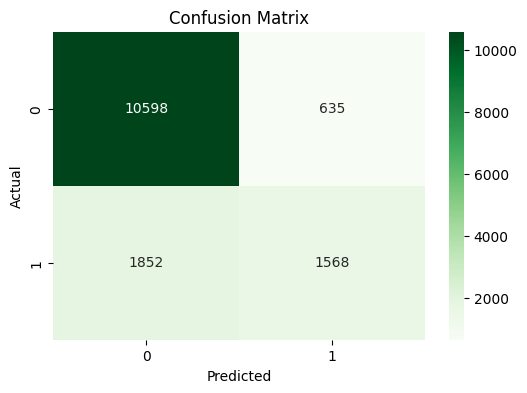

In [51]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_Te, y_pred_L), annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## **SVM**

In [52]:
from sklearn import svm 

In [53]:
svm = svm.SVC(kernel="rbf")

In [54]:
svm.fit(X_Tr_scaled, y_Tr)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [55]:
y_pred_SVM= svm.predict(X_Te_scaled)

In [56]:
print("SVM Results:")
print("Accuracy:", accuracy_score(y_Te, y_pred_SVM))
print("Confusion Matrix:")
print(confusion_matrix(y_Te, y_pred_SVM))
print("Classification Report:")
print(classification_report(y_Te, y_pred_SVM))

SVM Results:
Accuracy: 0.8587320002729817
Confusion Matrix:
[[10634   599]
 [ 1471  1949]]
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.95      0.91     11233
           1       0.76      0.57      0.65      3420

    accuracy                           0.86     14653
   macro avg       0.82      0.76      0.78     14653
weighted avg       0.85      0.86      0.85     14653



### **Confusion Matrix Figure**

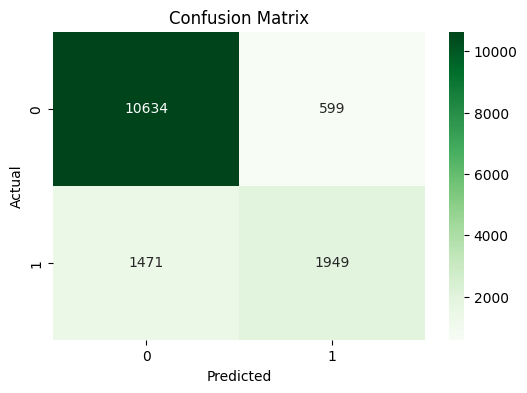

In [57]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_Te, y_pred_SVM), annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## **Naive Bayes**

In [58]:
from sklearn.naive_bayes import GaussianNB,BernoulliNB,MultinomialNB

In [59]:
GNB = GaussianNB()

In [60]:
GNB.fit(X_Tr , y_Tr)

,priors,None
,var_smoothing,1e-09


In [61]:
y_pred = GNB.predict(X_Te_scaled)

In [62]:
print("NB Results:")
print("Accuracy:", accuracy_score(y_Te, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_Te, y_pred))
print("Classification Report:")
print(classification_report(y_Te, y_pred))

NB Results:
Accuracy: 0.766600696103187
Confusion Matrix:
[[11233     0]
 [ 3420     0]]
Classification Report:
              precision    recall  f1-score   support

           0       0.77      1.00      0.87     11233
           1       0.00      0.00      0.00      3420

    accuracy                           0.77     14653
   macro avg       0.38      0.50      0.43     14653
weighted avg       0.59      0.77      0.67     14653



### **Confusion Matrix Figure**

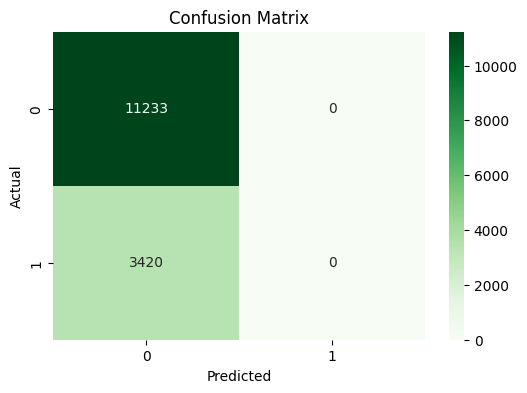

In [63]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_Te, y_pred), annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## **Decision Tree**

In [64]:
from sklearn.tree import DecisionTreeClassifier

In [65]:
DT = DecisionTreeClassifier()

In [66]:
DT.fit(X_Tr , y_Tr)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [67]:
y_pred_DT = DT.predict(X_Te_scaled)

In [68]:
print("DT Results:")
print("Accuracy:", accuracy_score(y_Te, y_pred_DT))
print("Confusion Matrix:")
print(confusion_matrix(y_Te, y_pred_DT))
print("Classification Report:")
print(classification_report(y_Te, y_pred_DT))

DT Results:
Accuracy: 0.4857025865010578
Confusion Matrix:
[[4142 7091]
 [ 445 2975]]
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.37      0.52     11233
           1       0.30      0.87      0.44      3420

    accuracy                           0.49     14653
   macro avg       0.60      0.62      0.48     14653
weighted avg       0.76      0.49      0.50     14653



## **Random Forest**

In [69]:
from sklearn.ensemble import RandomForestClassifier

In [70]:
R_F = RandomForestClassifier(n_estimators=800, random_state=101)

In [71]:
R_F.fit(X_Tr , y_Tr)

,n_estimators,800
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [72]:
y_pred_RF = R_F.predict(X_Te_scaled)

In [73]:
print("RF Results:")
print("Accuracy:", accuracy_score(y_Te, y_pred_RF))
print("Confusion Matrix:")
print(confusion_matrix(y_Te, y_pred_RF))
print("Classification Report:")
print(classification_report(y_Te, y_pred_RF))

RF Results:
Accuracy: 0.766600696103187
Confusion Matrix:
[[11233     0]
 [ 3420     0]]
Classification Report:
              precision    recall  f1-score   support

           0       0.77      1.00      0.87     11233
           1       0.00      0.00      0.00      3420

    accuracy                           0.77     14653
   macro avg       0.38      0.50      0.43     14653
weighted avg       0.59      0.77      0.67     14653



## **XGBoost**

In [74]:
import xgboost as xgb

In [75]:
xgb_clf = xgb.XGBClassifier(n_estimators=200, learning_rate=0.1, random_state=42)

xgb_clf.fit(X_Tr_scaled, y_Tr)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [76]:
y_pred_X= xgb_clf.predict(X_Te_scaled)

In [77]:
accuracy = accuracy_score(y_Te, y_pred_X)
accuracy

0.8813894765577015

## **Comparison Of Models Accuracies**

In [78]:
from matplotlib.ticker import PercentFormatter

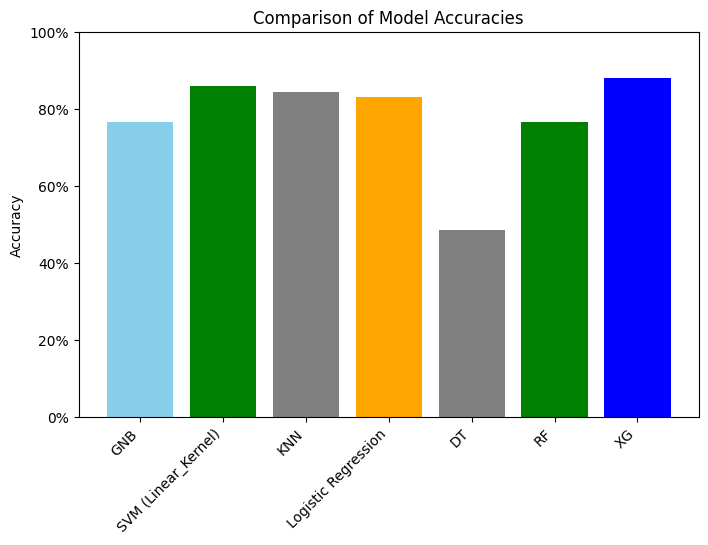

In [83]:
models = ["GNB", "SVM (Linear_Kernel)", "KNN", "Logistic Regression","DT","RF","XG"]

accuracies = [accuracy_score(y_Te, y_pred),accuracy_score(y_Te, y_pred_SVM),accuracy_score(y_Te, y_pred_knn),accuracy_score(y_Te, y_pred_L),accuracy_score(y_Te, y_pred_DT),accuracy_score(y_Te, y_pred_RF),accuracy_score(y_Te, y_pred_X)]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies, color=["skyblue", "green", "gray", "orange","Gray","green","blue"])
plt.ylim(0, 1)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.ylabel("Accuracy")
plt.xticks(rotation =45,ha="right")
plt.title("Comparison of Model Accuracies")
plt.show()